In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zlatan599/garbage-dataset-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-dataset-classification' dataset.
Path to dataset files: /kaggle/input/garbage-dataset-classification


In [2]:
!ls {path}

Garbage_Dataset_Classification


In [3]:
dataset_path = path + "/Garbage_Dataset_Classification/images"
!ls {dataset_path}

cardboard  glass  metal  paper	plastic  trash


## 1. ตรวจโครงสร้างและดูตัวอย่างภาพ
### dataset-image-visualizer

🔍 Inspecting dataset at: /kaggle/input/garbage-dataset-classification/Garbage_Dataset_Classification/images


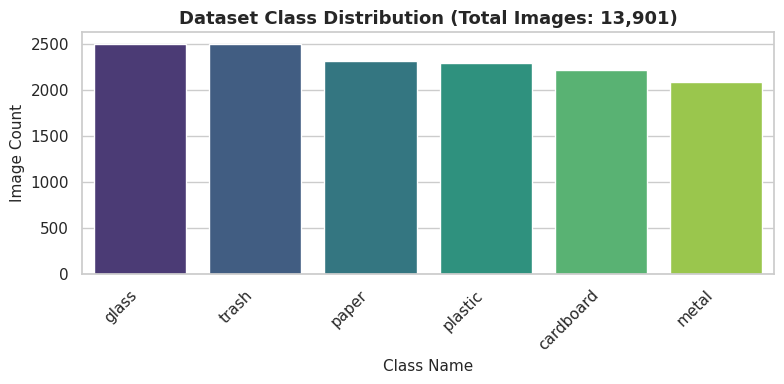

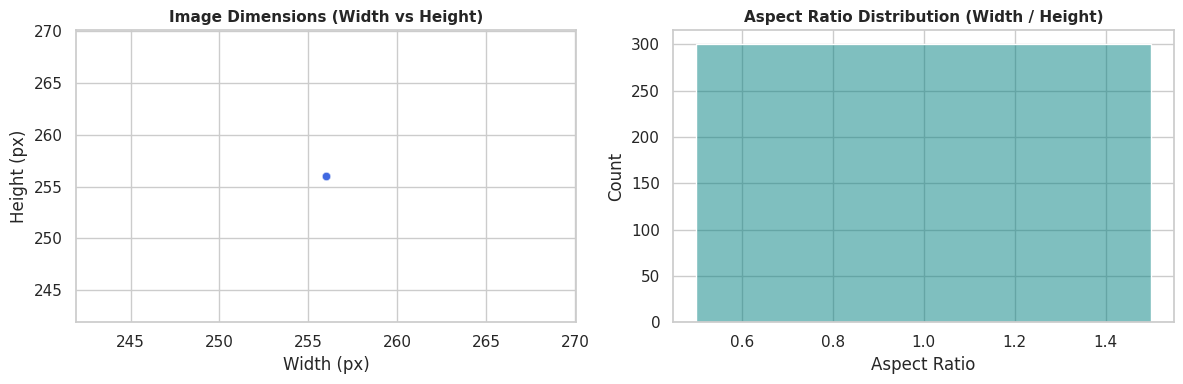

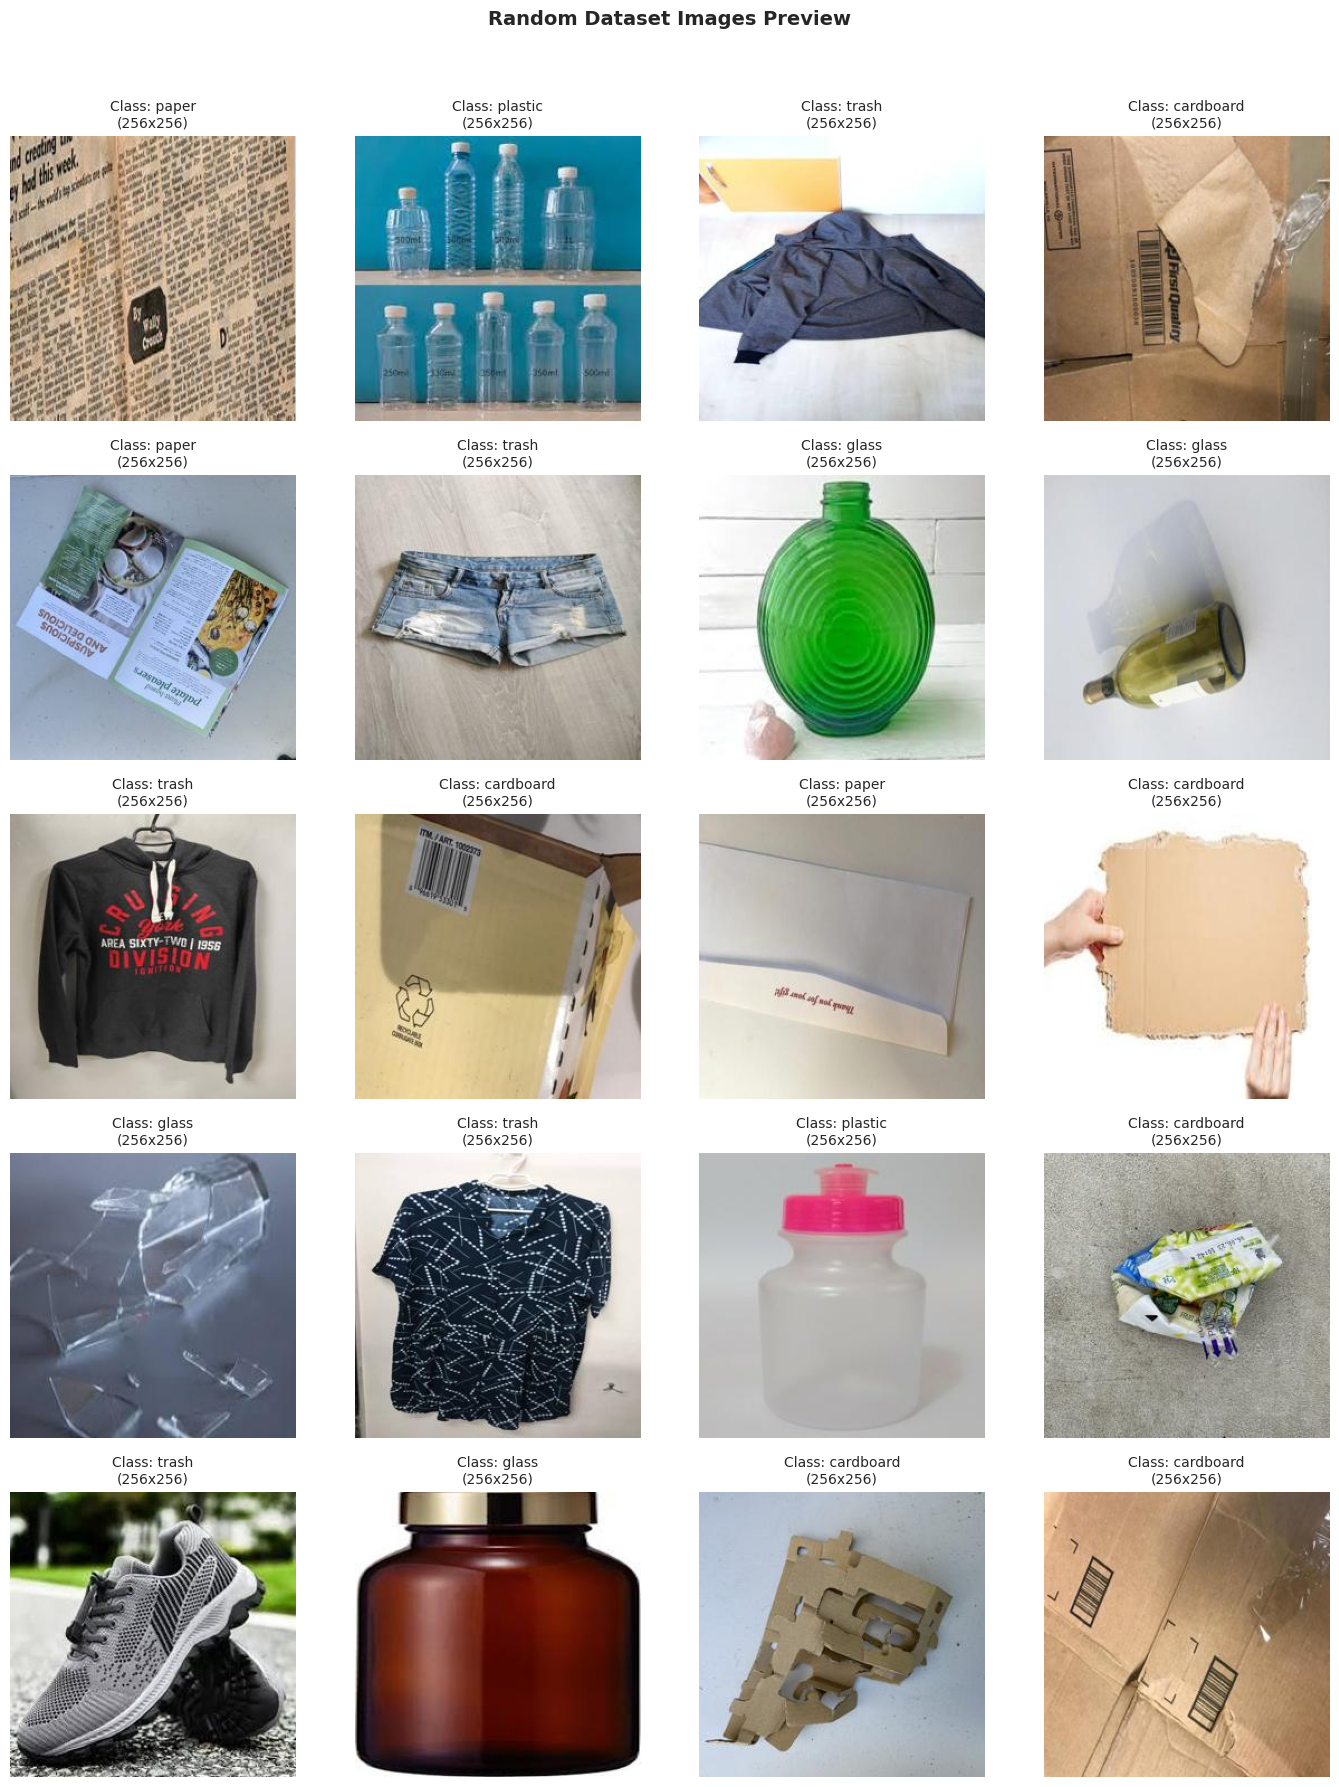

In [4]:
import os
import random
from pathlib import Path
from typing import List, Optional, Tuple, Union
import pandas as pd
from PIL import Image
import seaborn as sns

import matplotlib.pyplot as plt


def scan_image_dataset(dataset_path: Union[str, Path]) -> List[Tuple[str, str]]:
    """Scans a directory path structured by class subfolders or flat image folders."""
    data_path = Path(dataset_path)
    if not data_path.exists():
        raise FileNotFoundError(f"Dataset path not found: {data_path}")

    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    image_label_pairs = []

    subdirs = [d for d in data_path.iterdir() if d.is_dir()]
    if subdirs:
        for subdir in subdirs:
            cls_name = subdir.name
            for file in subdir.rglob("*.*"):
                if file.suffix.lower() in valid_extensions:
                    image_label_pairs.append((str(file), cls_name))
    else:
        for file in data_path.glob("*.*"):
            if file.suffix.lower() in valid_extensions:
                image_label_pairs.append((str(file), "Uncategorized"))

    return image_label_pairs


def plot_random_dataset_images(
    dataset_path: Union[str, Path],
    num_samples: int = 12,
    cols: int = 4,
    seed: Optional[int] = None,
) -> None:
    """Samples random images and displays them in a grid with class labels and resolution."""
    if seed is not None:
        random.seed(seed)

    image_label_pairs = scan_image_dataset(dataset_path)
    if not image_label_pairs:
        print(f"⚠️ No valid image files found in '{dataset_path}'.")
        return

    selected = random.sample(image_label_pairs, min(num_samples, len(image_label_pairs)))
    rows = (len(selected) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = axes.flatten() if len(selected) > 1 else [axes]

    for idx, (img_path, label) in enumerate(selected):
        try:
            with Image.open(img_path) as img:
                rgb_img = img.convert("RGB")
                axes[idx].imshow(rgb_img)
                axes[idx].set_title(f"Class: {label}\n({img.width}x{img.height})", fontsize=10)
        except Exception:
            axes[idx].set_title(f"Error loading:\n{label}", color="red", fontsize=9)
        axes[idx].axis("off")

    for j in range(len(selected), len(axes)):
        axes[j].axis("off")

    plt.suptitle("Random Dataset Images Preview", fontsize=14, y=1.02, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_dataset_statistics(
    dataset_path: Union[str, Path],
    max_dim_samples: int = 300,
) -> None:
    """Plots class balance bar plot and image dimension/aspect ratio distributions."""
    image_label_pairs = scan_image_dataset(dataset_path)
    if not image_label_pairs:
        print(f"⚠️ No valid images found in '{dataset_path}'.")
        return

    sns.set_theme(style="whitegrid")

    # 1. Class Distribution Barplot
    labels = [pair[1] for pair in image_label_pairs]
    label_counts = pd.Series(labels).value_counts()

    plt.figure(figsize=(max(8, len(label_counts) * 0.5), 4))
    sns.barplot(x=label_counts.index, y=label_counts.values, hue=label_counts.index, palette="viridis", legend=False)
    plt.title(f"Dataset Class Distribution (Total Images: {len(image_label_pairs):,})", fontsize=13, fontweight="bold")
    plt.xlabel("Class Name", fontsize=11)
    plt.ylabel("Image Count", fontsize=11)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # 2. Dimensions and Aspect Ratio Check
    sampled_for_dim = random.sample(image_label_pairs, min(max_dim_samples, len(image_label_pairs)))
    widths, heights, aspect_ratios = [], [], []

    for img_path, _ in sampled_for_dim:
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
                aspect_ratios.append(round(w / h, 2))
        except Exception:
            continue

    if widths:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.scatterplot(x=widths, y=heights, alpha=0.6, color="royalblue", ax=axes[0])
        axes[0].set_title("Image Dimensions (Width vs Height)", fontsize=11, fontweight="bold")
        axes[0].set_xlabel("Width (px)")
        axes[0].set_ylabel("Height (px)")

        sns.histplot(aspect_ratios, kde=True, color="teal", ax=axes[1])
        axes[1].set_title("Aspect Ratio Distribution (Width / Height)", fontsize=11, fontweight="bold")
        axes[1].set_xlabel("Aspect Ratio")
        plt.tight_layout()
        plt.show()


def visualize_dataset(dataset_path: Union[str, Path], num_samples: int = 20) -> None:
    """Main visualization entry point executing random grid inspection and dataset metrics."""
    print(f"🔍 Inspecting dataset at: {dataset_path}")
    plot_dataset_statistics(dataset_path)
    plot_random_dataset_images(dataset_path, num_samples=num_samples)


visualize_dataset(dataset_path)

## 2. โหลด EfficientNet-B2 พร้อม pretrained weights และเปลี่ยน classifier
### pretrained-model-builder 

In [5]:
from typing import Any
import torch
from torchvision.models import get_model, get_model_weights

import torch.nn as nn


def create_pretrained_model(
    model_name: str,
    num_classes: int,
    freeze_backbone: bool = True,
    dropout: float = 0.2,
    seed: Optional[int] = 42,
) -> Tuple[nn.Module, Any]:
    """Creates a pretrained model, freezes the backbone, replaces the classifier head,

    and returns (model, transforms).
    """
    model_name_clean = model_name.strip().lower()

    # 1. Load weights and transforms
    weights_enum = get_model_weights(model_name_clean).DEFAULT
    model = get_model(model_name_clean, weights=weights_enum)
    transforms = weights_enum.transforms()

    # 2. Freeze backbone parameters
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # 3. Deterministic head replacement
    if seed is not None:
        torch.manual_seed(seed)

    # 4. Adapt classifier head for EfficientNet
    if hasattr(model, "classifier") and isinstance(model.classifier, nn.Sequential):
        last_idx = len(model.classifier) - 1
        for idx in reversed(range(len(model.classifier))):
            if isinstance(model.classifier[idx], nn.Linear):
                last_idx = idx
                break

        in_features = model.classifier[last_idx].in_features
        model.classifier[last_idx] = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features=in_features, out_features=num_classes),
        )
    elif hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features=in_features, out_features=num_classes)
    else:
        raise NotImplementedError(f"Classifier adaptation not mapped for '{model_name}'.")

    return model, transforms


# Create EfficientNet-B2 with 2 output classes
model, transform = create_pretrained_model(
    model_name="efficientnet_b2",
    num_classes=6,
    freeze_backbone=True,
    dropout=0.2,
)

print(f"Model architecture: efficientnet_b2")
print(f"Base transforms:\n{transform}")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 173MB/s] 


Model architecture: efficientnet_b2
Base transforms:
ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


In [6]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [7]:
import subprocess
import sys
from typing import Sequence


try:
    from torchinfo import summary
    print("✅ Successfully imported summary from torchinfo.")
except ImportError:
    print("📦 'torchinfo' is not installed. Installing now...")
    try:
        get_ipython().system("pip install torchinfo")
        from torchinfo import summary
    except NameError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "torchinfo"])
    print("✅ Successfully imported summary from torchinfo.")


def inspect_model(
    model: nn.Module,
    input_size: Tuple[int, ...] = (1, 3, 288, 288),
    col_names: Sequence[str] = ("input_size", "output_size", "num_params", "trainable"),
    depth: int = 3,
    verbose: int = 1,
):
    """Summarizes a PyTorch model ensuring correct device allocation and input shape."""
    device = next(model.parameters()).device if list(model.parameters()) else "cpu"
    model.eval()

    return summary(
        model=model,
        input_size=input_size,
        device=device,
        col_names=list(col_names),
        depth=depth,
    )


inspect_model(model)

📦 'torchinfo' is not installed. Installing now...
✅ Successfully imported summary from torchinfo.


Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [1, 3, 288, 288]          [1, 6]                    --                        Partial
├─Sequential: 1-1                                       [1, 3, 288, 288]          [1, 1408, 9, 9]           --                        False
│    └─Conv2dNormActivation: 2-1                        [1, 3, 288, 288]          [1, 32, 144, 144]         --                        False
│    │    └─Conv2d: 3-1                                 [1, 3, 288, 288]          [1, 32, 144, 144]         (864)                     False
│    │    └─BatchNorm2d: 3-2                            [1, 32, 144, 144]         [1, 32, 144, 144]         (64)                      False
│    │    └─SiLU: 3-3                                   [1, 32, 144, 144]         [1, 32, 144, 144]         --                        --
│    └─Sequential

### 2.1 สร้าง data augmentation

In [8]:
import torchvision

augment_transforms = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    torchvision.transforms.RandomRotation(degrees=20),
    transform
])
augment_transforms
    

Compose(
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.2, 0.2))
    RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
    ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)
)

## 3. สร้าง Dataset, DataLoader และ Image Transform
### dataset-dataloader-builder

In [9]:
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torchvision import datasets

class DatasetFromSubset(Dataset):
    """Wrapper to apply transforms on subsets derived from random_split."""

    def __init__(self, subset: Subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx: int):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self) -> int:
        return len(self.subset)


def create_dataloaders(
    dataset_path: Union[str, Path],
    transform=transform,
    batch_size: int = 32,
    train_split: float = 0.8,
    val_split: float = 0.1,
    test_split: float = 0.1,
    num_workers: int = 2,
    seed: int = 42,
) -> Tuple[DataLoader, DataLoader, DataLoader, List[str]]:
    """Builds train, val, and test DataLoaders (80/10/10 split) using the specified transform."""
    data_path = Path(dataset_path)
    if not data_path.exists():
        raise FileNotFoundError(f"Dataset path not found: {data_path}")

    raw_dataset = datasets.ImageFolder(data_path, transform=None)
    class_names = raw_dataset.classes

    total_size = len(raw_dataset)
    val_size = int(total_size * val_split)
    test_size = int(total_size * test_split)
    train_size = total_size - val_size - test_size

    generator = torch.Generator().manual_seed(seed)
    train_sub, val_sub, test_sub = random_split(
        raw_dataset, [train_size, val_size, test_size], generator=generator
    )

    train_data = DatasetFromSubset(train_sub, transform=augment_transforms)
    val_data = DatasetFromSubset(val_sub, transform=transform)
    test_data = DatasetFromSubset(test_sub, transform=transform)

    train_dataloader = DataLoader(
        train_data,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=num_workers > 0,
    )

    val_dataloader = DataLoader(
        val_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=num_workers > 0,
    )

    test_dataloader = DataLoader(
        test_data,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    return train_dataloader, val_dataloader, test_dataloader, class_names, raw_dataset


train_loader, val_loader, test_loader, class_names, raw_dataset = create_dataloaders(
    dataset_path=dataset_path,
    transform=transform,
    train_split=0.8,
    val_split=0.1,
    test_split=0.1,
)

# กระดาษแข็ง แก้ว โลหะ พลาสติก กระดาษ ขยะ
print(f"Classes: {class_names}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train batches: 348 | Val batches: 44 | Test batches: 44


In [10]:
print(f"total dataset {len(raw_dataset)} ")
print(f"train dataset {len(train_loader.dataset)} ")
print(f"validation dataset {len(val_loader.dataset)} ")
print(f"test dataset {len(test_loader.dataset)} ")

total dataset 13901 
train dataset 11121 
validation dataset 1390 
test dataset 1390 


In [11]:
batch_image, batch_labels = next(iter(train_loader))
print(f"Batch image shape: {batch_image.shape}")
print(f"Batch labels shape: {batch_labels.shape}")

Batch image shape: torch.Size([32, 3, 288, 288])
Batch labels shape: torch.Size([32])


In [12]:
pred = model(batch_image)
print(f"Prediction shape: {pred.shape}")
print(f"Prediction: {pred}")

Prediction shape: torch.Size([32, 6])
Prediction: tensor([[ 1.6924e-01,  1.2713e-01, -2.2197e-02, -6.8922e-02,  6.3405e-03,
         -3.1811e-01],
        [-2.5225e-01, -3.3171e-02,  3.8634e-02,  5.3912e-02,  1.2052e-01,
          1.3137e-01],
        [-1.5843e-01,  1.9334e-02,  1.9769e-01,  8.0983e-02, -1.8833e-01,
         -1.2625e-01],
        [-1.3001e-01,  1.6941e-01, -2.2105e-01,  4.7035e-02,  1.1082e-01,
         -1.3984e-01],
        [ 1.9875e-01,  4.1047e-02, -8.7978e-02,  1.3657e-01,  1.2556e-03,
          1.3063e-01],
        [-1.4466e-01,  2.6820e-03,  6.1458e-02,  1.2360e-01, -9.6182e-02,
         -2.7683e-01],
        [-1.6595e-01,  9.8462e-02, -1.1437e-01,  8.4715e-03,  9.0681e-02,
         -2.7633e-01],
        [-2.4349e-01,  1.7765e-01, -1.6298e-06, -1.7313e-01,  1.8482e-01,
          1.0706e-01],
        [-1.1381e-01,  1.6507e-01, -5.2422e-02,  2.0809e-01, -3.2609e-02,
         -1.1412e-01],
        [ 7.1760e-02, -1.6359e-01, -1.8632e-02, -1.3052e-01, -2.1182e-01,
   

### 3.1 ดูรูปภาพตัวอย่างจาก train loader
### train-loader-augmented-visualizer

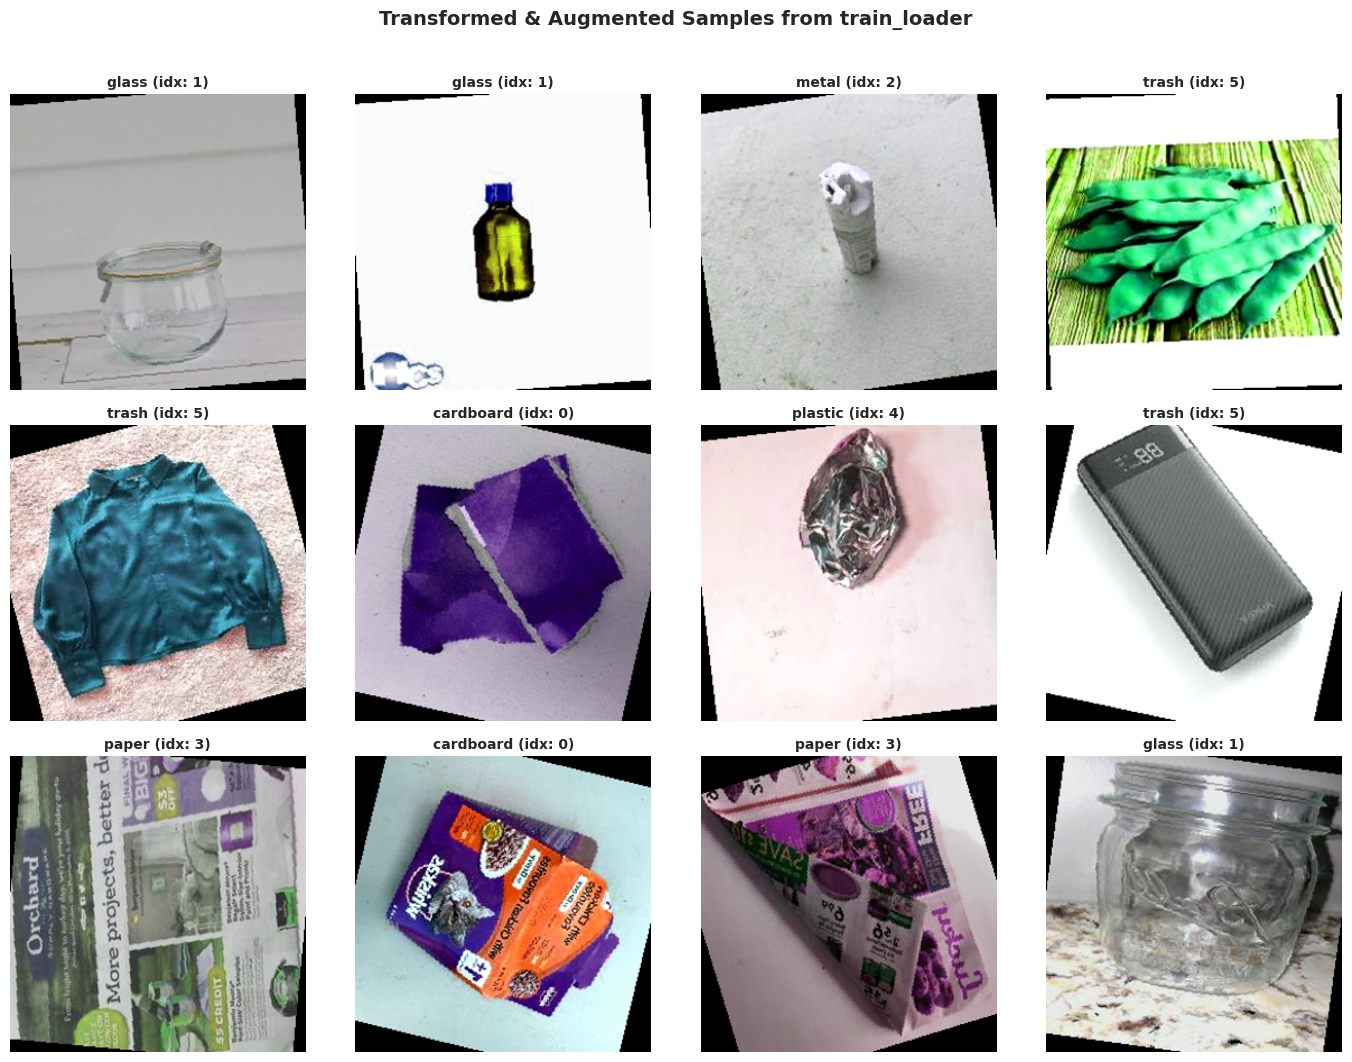

In [13]:
def visualize_train_loader_samples(
    train_loader: DataLoader,
    class_names: Optional[List[str]] = None,
    num_samples: int = 12,
    cols: int = 4,
    mean: Tuple[float, float, float] = (0.485, 0.456, 0.406),
    std: Tuple[float, float, float] = (0.229, 0.224, 0.225),
    figsize: Optional[Tuple[int, int]] = None,
) -> None:
    """Visualizes transformed/augmented images directly from train_loader."""
    collected_images = []
    collected_labels = []

    # 1. Fetch images from the DataLoader iterator
    for images, labels in train_loader:
        collected_images.append(images)
        collected_labels.append(labels)
        if sum(x.size(0) for x in collected_images) >= num_samples:
            break

    if not collected_images:
        print("⚠️ Warning: No batches retrieved from train_loader.")
        return

    # Concatenate and slice to exact sample size
    batch_images = torch.cat(collected_images, dim=0)[:num_samples]
    batch_labels = torch.cat(collected_labels, dim=0)[:num_samples]

    rows = (num_samples + cols - 1) // cols
    if figsize is None:
        figsize = (cols * 3.5, rows * 3.5)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if num_samples > 1 else [axes]

    # Pre-calculate un-normalization vectors
    mean_tensor = torch.tensor(mean).view(-1, 1, 1)
    std_tensor = torch.tensor(std).view(-1, 1, 1)

    for idx in range(num_samples):
        img = batch_images[idx].detach().cpu()
        label_idx = batch_labels[idx].item()

        # 2. Revert normalization (if 3-channel RGB image)
        if img.ndim == 3 and img.shape[0] == 3:
            img = img * std_tensor + mean_tensor
            img = torch.clamp(img, 0.0, 1.0)
            img_np = img.permute(1, 2, 0).numpy()
            cmap = None
        elif img.ndim == 3 and img.shape[0] == 1:
            img_np = img.squeeze(0).numpy()
            cmap = "gray"
        else:
            img_np = img.numpy()
            cmap = None

        # 3. Resolve class title
        if class_names and 0 <= label_idx < len(class_names):
            title = f"{class_names[label_idx]} (idx: {label_idx})"
        else:
            title = f"Class: {label_idx}"

        axes[idx].imshow(img_np, cmap=cmap)
        axes[idx].set_title(title, fontsize=10, fontweight="bold")
        axes[idx].axis("off")

    # Turn off leftover unused axes
    for j in range(num_samples, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Transformed & Augmented Samples from train_loader", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


visualize_train_loader_samples(train_loader, class_names=class_names)

## 4. Fine-tune โมเดล พร้อมดูค่า Loss และ Accuracy
### model-trainer-visualizer

🚀 Training started on device: cuda
Epoch [01/05] | Train Loss: 0.9286 - Train Acc: 69.51% | Val Loss: 0.5800 - Val Acc: 82.73%
Epoch [02/05] | Train Loss: 0.6808 - Train Acc: 76.34% | Val Loss: 0.5253 - Val Acc: 84.24%
Epoch [03/05] | Train Loss: 0.6571 - Train Acc: 77.12% | Val Loss: 0.4693 - Val Acc: 85.40%
Epoch [04/05] | Train Loss: 0.6235 - Train Acc: 78.24% | Val Loss: 0.4617 - Val Acc: 85.11%
Epoch [05/05] | Train Loss: 0.6234 - Train Acc: 78.02% | Val Loss: 0.4336 - Val Acc: 85.32%


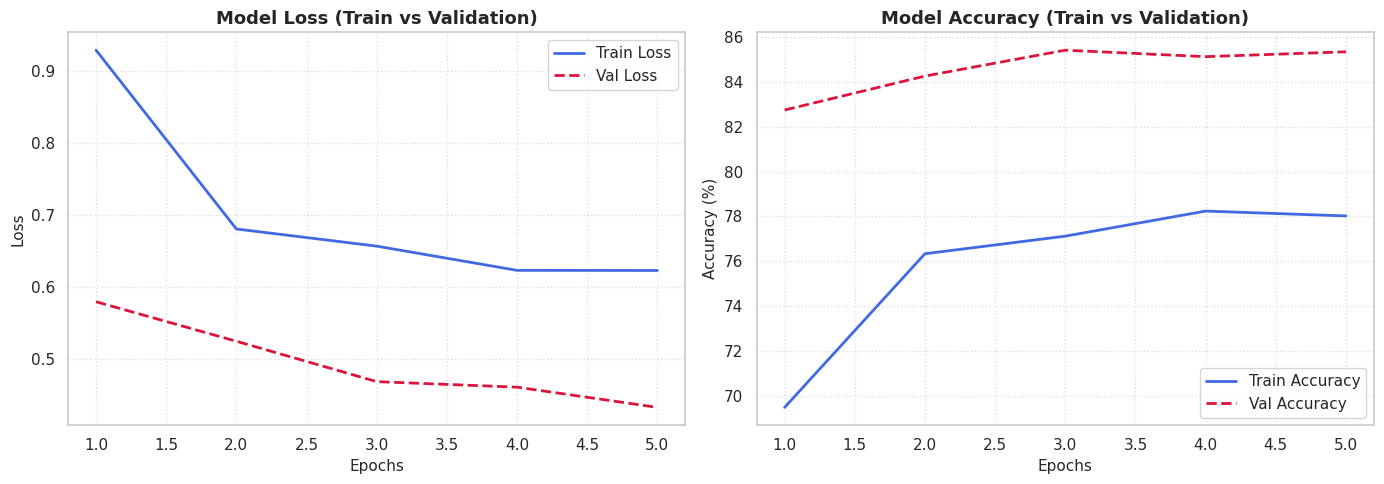

In [14]:
import copy
from typing import Dict

def setup_loss_and_optimizer(
    model: nn.Module,
    problem_type: str = "multiclass",
    learning_rate: float = 1e-3,
    weight_decay: float = 1e-4,
    label_smoothing: float = 0.0,
) -> Tuple[nn.Module, torch.optim.Optimizer]:
    """Configures task-appropriate criterion and optimizer."""
    if problem_type.lower() == "multiclass":
        loss_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    elif problem_type.lower() == "binary":
        loss_fn = nn.BCEWithLogitsLoss()
    else:
        raise ValueError("problem_type must be either 'multiclass' or 'binary'")

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(
        params=trainable_params, lr=learning_rate, weight_decay=weight_decay
    )
    return loss_fn, optimizer


class EarlyStopping:
    """Monitors validation loss to stop early and restore best weights."""

    def __init__(
        self,
        patience: int = 5,
        min_delta: float = 1e-4,
        monitor: str = "val_loss",
        mode: str = "min",
        restore_best_weights: bool = True,
    ):
        self.patience = patience
        self.min_delta = min_delta
        self.monitor = monitor
        self.mode = mode
        self.restore_best_weights = restore_best_weights
        self.counter = 0
        self.best_score: Optional[float] = None
        self.early_stop = False
        self.best_weights: Optional[Dict[str, torch.Tensor]] = None

    def __call__(self, current_metric: float, model: nn.Module) -> bool:
        score = -current_metric if self.mode == "min" else current_metric

        if self.best_score is None:
            self.best_score = score
            self.best_weights = copy.deepcopy(model.state_dict())
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_weights = copy.deepcopy(model.state_dict())
            self.counter = 0

        return self.early_stop

    def restore_model(self, model: nn.Module) -> None:
        if self.restore_best_weights and self.best_weights is not None:
            model.load_state_dict(self.best_weights)


def train_model(
    model: nn.Module,
    train_dataloader: DataLoader,
    val_dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    epochs: int = 20,
    device: Optional[Union[str, torch.device]] = None,
    patience: int = 5,
    scheduler: Optional[torch.optim.lr_scheduler._LRScheduler] = None,
) -> Tuple[nn.Module, Dict[str, List[float]]]:
    """PyTorch training and validation loop with Early Stopping and Metric History."""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    early_stopper = EarlyStopping(
        patience=patience, monitor="val_loss", mode="min", restore_best_weights=True
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    print(f"🚀 Training started on device: {device}")
    for epoch in range(1, epochs + 1):
        # Training Phase
        model.train()
        running_train_loss = 0.0
        train_correct = 0
        train_total = 0

        for X, y in train_dataloader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(X)
            loss = loss_fn(outputs, y)
            preds = torch.argmax(outputs, dim=1)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * X.size(0)
            train_correct += (preds == y).sum().item()
            train_total += X.size(0)

        epoch_train_loss = running_train_loss / train_total
        epoch_train_acc = (train_correct / train_total) * 100.0

        # Validation Phase
        model.eval()
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.inference_mode():
            for X_val, y_val in val_dataloader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                val_outputs = model(X_val)
                v_loss = loss_fn(val_outputs, y_val)
                v_preds = torch.argmax(val_outputs, dim=1)

                running_val_loss += v_loss.item() * X_val.size(0)
                val_correct += (v_preds == y_val).sum().item()
                val_total += X_val.size(0)

        epoch_val_loss = running_val_loss / val_total
        epoch_val_acc = (val_correct / val_total) * 100.0

        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        print(
            f"Epoch [{epoch:02d}/{epochs:02d}] | "
            f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
            f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.2f}%"
        )

        if early_stopper(epoch_val_loss, model):
            print(f"⏹️ Early stopping triggered at Epoch {epoch}. Restoring best weights...")
            early_stopper.restore_model(model)
            break

    if not early_stopper.early_stop:
        early_stopper.restore_model(model)

    return model, history


def plot_training_history(history: Dict[str, List[float]]) -> None:
    """Plots Train vs Validation Loss and Accuracy side-by-side."""
    epochs_range = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(14, 5))

    # Loss curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], label="Train Loss", color="royalblue", lw=2)
    plt.plot(epochs_range, history["val_loss"], label="Val Loss", color="crimson", lw=2, linestyle="--")
    plt.title("Model Loss (Train vs Validation)", fontsize=13, fontweight="bold")
    plt.xlabel("Epochs", fontsize=11)
    plt.ylabel("Loss", fontsize=11)
    plt.legend(frameon=True)
    plt.grid(True, linestyle=":", alpha=0.6)

    # Accuracy curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_acc"], label="Train Accuracy", color="royalblue", lw=2)
    plt.plot(epochs_range, history["val_acc"], label="Val Accuracy", color="crimson", lw=2, linestyle="--")
    plt.title("Model Accuracy (Train vs Validation)", fontsize=13, fontweight="bold")
    plt.xlabel("Epochs", fontsize=11)
    plt.ylabel("Accuracy (%)", fontsize=11)
    plt.legend(frameon=True)
    plt.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()


# Set up criterion and optimizer
loss_fn, optimizer = setup_loss_and_optimizer(
    model=model,
    problem_type="multiclass",
    learning_rate=1e-3,
    weight_decay=1e-4,
)

# Train model
model, history = train_model(
    model=model,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=5,
    patience=4,
)

# Visualize curves
plot_training_history(history)

## 5. ประเมินโมเดลกับชุดทดสอบ
### model-test-evaluator

📊 TEST EVALUATION SUMMARY
Test Loss        : 0.4385
Total Samples    : 1,390
Correct Count    : 1,197 / 1,390
Test Accuracy    : 86.12%

Classification Report:

              precision    recall  f1-score   support

   cardboard       0.86      0.83      0.84       190
       glass       0.91      0.88      0.89       240
       metal       0.74      0.89      0.81       213
       paper       0.89      0.86      0.88       253
     plastic       0.89      0.78      0.83       232
       trash       0.88      0.92      0.90       262

    accuracy                           0.86      1390
   macro avg       0.86      0.86      0.86      1390
weighted avg       0.87      0.86      0.86      1390



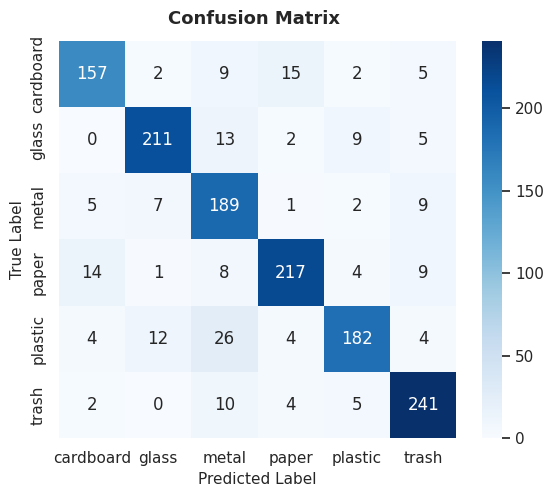

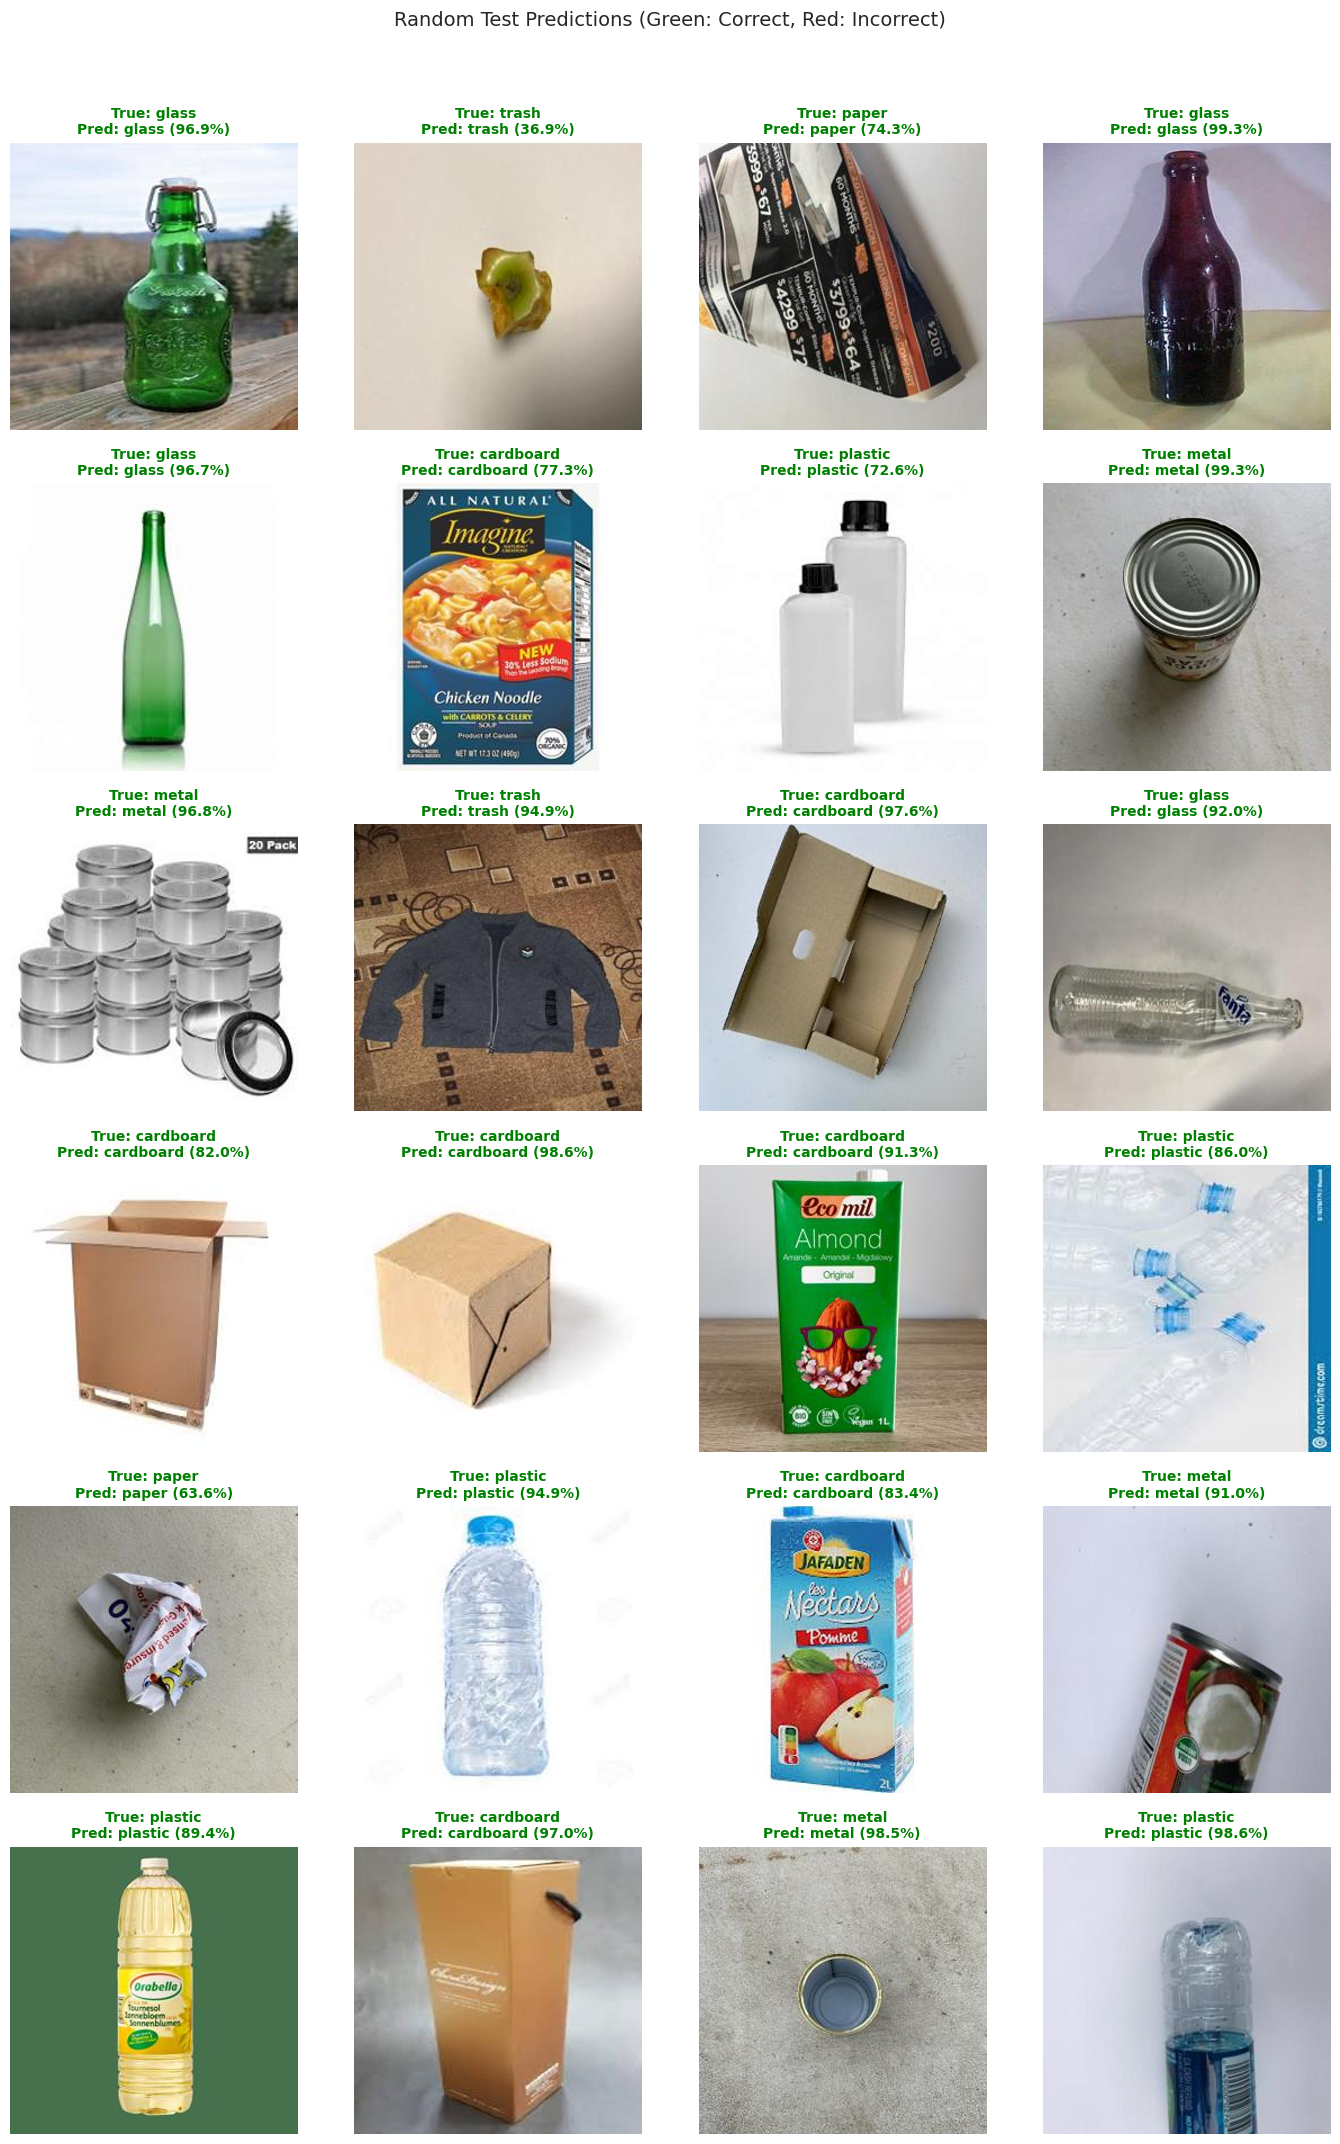

In [15]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_test_model(
    model: nn.Module,
    test_dataloader: DataLoader,
    class_names: List[str],
    loss_fn: Optional[nn.Module] = None,
    device: Optional[Union[str, torch.device]] = None,
) -> Tuple[float, int, int, np.ndarray, np.ndarray]:
    """Evaluates model performance over the test DataLoader."""
    if device is None:
        device = next(model.parameters()).device
    else:
        model = model.to(device)

    model.eval()
    total_correct = 0
    total_samples = 0
    running_loss = 0.0

    all_preds_list = []
    all_targets_list = []

    with torch.inference_mode():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)

            if loss_fn is not None:
                loss = loss_fn(outputs, y)
                running_loss += loss.item() * X.size(0)

            if outputs.ndim > 1 and outputs.shape[-1] > 1:
                preds = torch.argmax(outputs, dim=1)
            else:
                preds = (torch.sigmoid(outputs.squeeze(-1)) >= 0.5).long()

            total_correct += (preds == y).sum().item()
            total_samples += X.size(0)

            all_preds_list.extend(preds.cpu().numpy())
            all_targets_list.extend(y.cpu().numpy())

    all_preds = np.array(all_preds_list)
    all_targets = np.array(all_targets_list)
    test_acc = (total_correct / total_samples) * 100.0

    print("=" * 60)
    print("📊 TEST EVALUATION SUMMARY")
    print("=" * 60)
    if loss_fn is not None:
        print(f"Test Loss        : {running_loss / total_samples:.4f}")
    print(f"Total Samples    : {total_samples:,}")
    print(f"Correct Count    : {total_correct:,} / {total_samples:,}")
    print(f"Test Accuracy    : {test_acc:.2f}%")
    print("=" * 60)

    print("\nClassification Report:\n")
    print(classification_report(all_targets, all_preds, target_names=class_names))

    return test_acc, total_correct, total_samples, all_preds, all_targets


def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: List[str],
    normalize: Optional[str] = None,
    figsize: Tuple[int, int] = (6, 5),
    cmap: str = "Blues",
) -> None:
    """Plots a labeled confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred, normalize=normalize)
    fmt = ".2f" if normalize else "d"

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        xticklabels=class_names,
        yticklabels=class_names,
        cbar=True,
        square=True,
    )
    plt.title(f"Confusion Matrix {'(Normalized)' if normalize else ''}", fontsize=13, fontweight="bold", pad=12)
    plt.xlabel("Predicted Label", fontsize=11)
    plt.ylabel("True Label", fontsize=11)
    plt.tight_layout()
    plt.show()


def plot_random_predictions(
    model: nn.Module,
    test_dataloader: DataLoader,
    class_names: List[str],
    num_images: int = 12,
    cols: int = 4,
    mean: Tuple[float, float, float] = (0.485, 0.456, 0.406),
    std: Tuple[float, float, float] = (0.229, 0.224, 0.225),
    seed: Optional[int] = 42,
) -> None:
    """Samples and visualizes random test predictions with un-normalized images."""
    if seed is not None:
        random.seed(seed)
        torch.manual_seed(seed)

    device = next(model.parameters()).device
    model.eval()

    collected_images = []
    collected_targets = []

    for X, y in test_dataloader:
        collected_images.append(X)
        collected_targets.append(y)
        if sum(len(x) for x in collected_images) >= num_images * 3:
            break

    all_X = torch.cat(collected_images, dim=0)
    all_y = torch.cat(collected_targets, dim=0)

    indices = random.sample(range(len(all_X)), min(num_images, len(all_X)))
    sample_images = all_X[indices]
    sample_targets = all_y[indices]

    with torch.inference_mode():
        logits = model(sample_images.to(device))
        preds = torch.argmax(logits, dim=1).cpu()
        probs = torch.softmax(logits, dim=1).cpu()

    rows = (len(indices) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
    axes = axes.flatten() if len(indices) > 1 else [axes]

    mean_tensor = torch.tensor(mean).view(3, 1, 1)
    std_tensor = torch.tensor(std).view(3, 1, 1)

    for i, idx in enumerate(range(len(indices))):
        img = sample_images[idx].cpu()
        img = img * std_tensor + mean_tensor
        img = torch.clamp(img, 0.0, 1.0)
        img = img.permute(1, 2, 0).numpy()

        true_label = class_names[sample_targets[idx].item()]
        pred_label = class_names[preds[idx].item()]
        conf = probs[idx][preds[idx]].item() * 100.0

        is_correct = preds[idx].item() == sample_targets[idx].item()
        color = "green" if is_correct else "red"

        axes[i].imshow(img)
        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label} ({conf:.1f}%)",
            color=color,
            fontsize=10,
            fontweight="bold",
        )
        axes[i].axis("off")

    for j in range(len(indices), len(axes)):
        axes[j].axis("off")

    plt.suptitle("Random Test Predictions (Green: Correct, Red: Incorrect)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# 1. Run evaluation on test loader
test_acc, total_correct, total_samples, all_preds, all_targets = evaluate_test_model(
    model=model,
    test_dataloader=test_loader,
    class_names=class_names,
    loss_fn=loss_fn,
)

# 2. Confusion matrix
plot_confusion_matrix(all_targets, all_preds, class_names=class_names)

# 3. Random prediction preview
plot_random_predictions(
    model=model,
    test_dataloader=test_loader,
    class_names=class_names,
    num_images=24,
    cols=4,
)

# กระดาษแข็ง แก้ว โลหะ พลาสติก กระดาษ ขยะ

## 6. ใช้ gradio ทำนายภาพใหม่
### gradio-interface-builder

In [16]:
import os
import random
import shutil
import subprocess
import sys
from pathlib import Path
from typing import Dict, List, Optional

from PIL import Image
import torch
import torch.nn as nn

try:
    import gradio as gr
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gradio"])
    import gradio as gr


def create_gradio_app(
    model: nn.Module,
    transform_fn,
    class_names: List[str],
    title: str = "Garbage Classification Demo",
    description: str = "Upload an image of garbage/waste to predict its category.",
    examples: Optional[List[str]] = None,
) -> gr.Blocks:
    """Builds a Gradio Blocks application for garbage classification inference."""
    device = next(model.parameters()).device
    model.eval()

    def predict(image: Optional[Image.Image]) -> Dict[str, float]:
        if image is None:
            return {}

        # 1. Preprocessing
        img_rgb = image.convert("RGB")
        img_tensor = transform_fn(img_rgb).unsqueeze(0).to(device)

        # 2. Model Inference
        with torch.inference_mode():
            logits = model(img_tensor)
            probabilities = torch.softmax(logits, dim=1).squeeze(0)

        # 3. Postprocessing
        confidences = {
            class_names[i]: float(probabilities[i].item())
            for i in range(len(class_names))
        }
        return confidences

    # Build Gradio UI with gr.Blocks
    with gr.Blocks(theme=gr.themes.Soft(), title=title) as demo:
        gr.Markdown(f"# {title}")
        gr.Markdown(description)

        with gr.Row():
            with gr.Column(scale=1):
                input_image = gr.Image(type="pil", label="Input Image")
                with gr.Row():
                    btn_clear = gr.ClearButton(components=[input_image], value="Clear")
                    btn_submit = gr.Button("Predict", variant="primary")

            with gr.Column(scale=1):
                output_label = gr.Label(
                    num_top_classes=len(class_names), label="Predictions"
                )

        btn_submit.click(fn=predict, inputs=input_image, outputs=output_label)
        input_image.change(fn=predict, inputs=input_image, outputs=output_label)

        if examples:
            gr.Examples(examples=examples, inputs=input_image)

    return demo


# Copy sample example images locally to prevent Gradio InvalidPathError
example_dir = Path("example_images")
example_dir.mkdir(parents=True, exist_ok=True)

example_image_paths = []
for sample in random.sample(raw_dataset.samples, min(6, len(raw_dataset.samples))):
    src = Path(sample[0])
    dst = example_dir / src.name
    shutil.copy(src, dst)
    example_image_paths.append(str(dst))

# Launch Gradio interface with allowed_paths
demo = create_gradio_app(
    model=model,
    transform_fn=transform,
    class_names=class_names,
    examples=example_image_paths,
)

demo.launch(share=True, allowed_paths=[str(path), str(example_dir.resolve())])


/tmp/ipykernel_2196/86774808.py:53: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title=title) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7e71378d127baf6e4e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 7. บันทึกโมเดลหลังการฝึก
### model-artifact-saver

In [17]:
def save_model_artifacts(
    model: nn.Module,
    class_names: List[str],
    transform: Optional[Any] = None,
    model_filename: str = "model.pth",
    classes_filename: str = "class_names.txt",
    transform_filename: str = "transform.pth",
    save_dir: Optional[Union[str, Path]] = None,
) -> Tuple[Path, Path, Optional[Path]]:
    """Saves model state_dict (.pth), class labels (.txt), and transforms (.pth) into the target directory."""
    # 1. Resolve target directory
    target_dir = Path(save_dir) if save_dir is not None else Path.cwd()
    target_dir.mkdir(parents=True, exist_ok=True)

    # 2. Format output file paths
    if not model_filename.endswith(".pth"):
        model_filename = f"{model_filename}.pth"
    if not classes_filename.endswith(".txt"):
        classes_filename = f"{classes_filename}.txt"
    if not transform_filename.endswith(".pth"):
        transform_filename = f"{transform_filename}.pth"

    model_path = target_dir / model_filename
    classes_path = target_dir / classes_filename
    transform_path = target_dir / transform_filename if transform is not None else None

    # 3. Save model state_dict
    torch.save(obj=model.state_dict(), f=str(model_path))

    # 4. Save class_names into .txt (one label per line)
    with open(classes_path, mode="w", encoding="utf-8") as f:
        for name in class_names:
            f.write(f"{name}\n")

    # 5. Save transform object
    if transform is not None and transform_path is not None:
        torch.save(obj=transform, f=str(transform_path))

    print("=" * 60)
    print("💾 ARTIFACTS SAVED SUCCESSFULLY")
    print("=" * 60)
    print(f"Model Weights (.pth) : {model_path.resolve()}")
    print(f"Class Names (.txt)   : {classes_path.resolve()} ({len(class_names)} classes)")
    if transform_path is not None:
        print(f"Transform (.pth)     : {transform_path.resolve()}")
    print("=" * 60)

    return model_path, classes_path, transform_path


def load_model_artifacts(
    model: nn.Module,
    model_filename: str = "model.pth",
    classes_filename: str = "class_names.txt",
    transform_filename: Optional[str] = "transform.pth",
    load_dir: Optional[Union[str, Path]] = None,
    device: Optional[Union[str, torch.device]] = None,
) -> Tuple[nn.Module, List[str], Optional[Any]]:
    """Loads saved model state_dict (.pth), class names (.txt), and transforms (.pth) from disk."""
    source_dir = Path(load_dir) if load_dir is not None else Path.cwd()
    model_path = source_dir / model_filename
    classes_path = source_dir / classes_filename

    if not model_path.exists():
        raise FileNotFoundError(f"Model weight file not found at: {model_path}")
    if not classes_path.exists():
        raise FileNotFoundError(f"Class names file not found at: {classes_path}")

    # 1. Load class labels
    with open(classes_path, mode="r", encoding="utf-8") as f:
        loaded_classes = [line.strip() for line in f if line.strip()]

    # 2. Determine target device
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 3. Restore state_dict into model architecture
    model.load_state_dict(torch.load(f=str(model_path), map_location=device))
    model.to(device)
    model.eval()

    # 4. Load transform if available
    loaded_transform = None
    if transform_filename is not None:
        transform_path = source_dir / transform_filename
        if transform_path.exists():
            loaded_transform = torch.load(f=str(transform_path), map_location="cpu")

    print(f"✅ Loaded model weights from: {model_path}")
    print(f"✅ Loaded {len(loaded_classes)} classes from: {classes_path}")
    if loaded_transform is not None:
        print(f"✅ Loaded transform from: {transform_path}")

    return model, loaded_classes, loaded_transform


# Save model, class_names, and transform
saved_model_path, saved_classes_path, saved_transform_path = save_model_artifacts(
    model=model,
    class_names=class_names,
    transform=transform,
    model_filename="efficientnet_b2_garbage.pth",
    classes_filename="class_names.txt",
    transform_filename="transform.pth",
)

💾 ARTIFACTS SAVED SUCCESSFULLY
Model Weights (.pth) : /content/efficientnet_b2_garbage.pth
Class Names (.txt)   : /content/class_names.txt (6 classes)
Transform (.pth)     : /content/transform.pth
